Cargar el archivo AprobacionCurso.xlsx


In [2]:
import pandas as pd

file_path = 'AprobacionCurso.xlsx'
df = pd.read_excel(file_path)

print("File loaded successfully. Here are the first 5 rows:")
print(df.head())
df.info()

File loaded successfully. Here are the first 5 rows:
   ID Año - Semestre      Felder  Examen_admisión  Nota_final Aprobo
0   1        2016-01   sensorial             4.67         3.1     si
1   2        2016-01      activo             4.17         2.1     no
2   3        2016-01      visual             4.50         3.1     si
3   4        2016-01      visual             3.83         1.6     no
4   5        2016-01  equilibrio             3.00         2.3     no
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               183 non-null    int64  
 1   Año - Semestre   183 non-null    object 
 2   Felder           183 non-null    object 
 3   Examen_admisión  181 non-null    float64
 4   Nota_final       183 non-null    float64
 5   Aprobo           183 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 8.7+ KB

Eliminar las variables ID, ano-semestre, Aprobo

In [3]:
df = df.drop(columns=['ID', 'Año - Semestre', 'Aprobo'])

print("Columns removed successfully. Here's the updated DataFrame information:")
df.info()

Columns removed successfully. Here's the updated DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Felder           183 non-null    object 
 1   Examen_admisión  181 non-null    float64
 2   Nota_final       183 non-null    float64
dtypes: float64(2), object(1)
memory usage: 4.4+ KB


aplica one hot encoding a la variable Felder y elimina la variable original

In [4]:
df = pd.get_dummies(df, columns=['Felder'], drop_first=True)

print("One-hot encoding applied to 'Felder' variable. Here's the updated DataFrame information:")
df.info()

One-hot encoding applied to 'Felder' variable. Here's the updated DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Examen_admisión    181 non-null    float64
 1   Nota_final         183 non-null    float64
 2   Felder_equilibrio  183 non-null    bool   
 3   Felder_intuitivo   183 non-null    bool   
 4   Felder_reflexivo   183 non-null    bool   
 5   Felder_secuencial  183 non-null    bool   
 6   Felder_sensorial   183 non-null    bool   
 7   Felder_verbal      183 non-null    bool   
 8   Felder_visual      183 non-null    bool   
dtypes: bool(7), float64(2)
memory usage: 4.2 KB


normaliza la variable Examen_admisión con minmax scaler

In [5]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Reshape 'Examen_admisión' column to a 2D array for scaling and add it as a new column
df['Examen_admision_scaled'] = scaler.fit_transform(df[['Examen_admisión']])

# Remove the original 'Examen_admisión' column
df = df.drop(columns=['Examen_admisión'])

# Define the file path to save the scaler
scaler_file_path = 'min_max_scaler.joblib'

# Save the fitted MinMaxScaler object
joblib.dump(scaler, scaler_file_path)

print("DataFrame después de normalizar y eliminar 'Examen_admisión':")
print(df.head())
print(f"El MinMaxScaler ha sido guardado exitosamente en: {scaler_file_path}")

DataFrame después de normalizar y eliminar 'Examen_admisión':
   Nota_final  Felder_equilibrio  Felder_intuitivo  Felder_reflexivo  \
0         3.1              False             False             False   
1         2.1              False             False             False   
2         3.1              False             False             False   
3         1.6              False             False             False   
4         2.3               True             False             False   

   Felder_secuencial  Felder_sensorial  Felder_verbal  Felder_visual  \
0              False              True          False          False   
1              False             False          False          False   
2              False             False          False           True   
3              False             False          False           True   
4              False             False          False          False   

   Examen_admision_scaled  
0                   0.934  
1               

Transforma true en 1 y false en 0 de toda las variables dummies

In [6]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

print("DataFrame after transforming boolean and 'Aprobo' columns:")
print(df.head())
df.info()

DataFrame after transforming boolean and 'Aprobo' columns:
   Nota_final  Felder_equilibrio  Felder_intuitivo  Felder_reflexivo  \
0         3.1                  0                 0                 0   
1         2.1                  0                 0                 0   
2         3.1                  0                 0                 0   
3         1.6                  0                 0                 0   
4         2.3                  1                 0                 0   

   Felder_secuencial  Felder_sensorial  Felder_verbal  Felder_visual  \
0                  0                 1              0              0   
1                  0                 0              0              0   
2                  0                 0              0              1   
3                  0                 0              0              1   
4                  0                 0              0              0   

   Examen_admision_scaled  
0                   0.934  
1                  

genera el modelo de refresion lineal multivariada y muestra los
coeficientes calculados. dame las metricas de evaluacion

In [7]:
# Handle missing values in 'Examen_admision_scaled' by filling with the mean
df['Examen_admision_scaled'].fillna(df['Examen_admision_scaled'].mean(), inplace=True)

# Verify no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df.drop(columns=['Nota_final'])
y = df['Nota_final']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display coefficients
print("\nCalculated Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE manually as squared=False is not supported
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
print("\nEvaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Missing values after imputation:
Nota_final                0
Felder_equilibrio         0
Felder_intuitivo          0
Felder_reflexivo          0
Felder_secuencial         0
Felder_sensorial          0
Felder_verbal             0
Felder_visual             0
Examen_admision_scaled    0
dtype: int64

Calculated Coefficients:
Felder_equilibrio: -0.0221
Felder_intuitivo: -0.5632
Felder_reflexivo: -0.1323
Felder_secuencial: -0.0419
Felder_sensorial: 0.0341
Felder_verbal: 0.1281
Felder_visual: -0.0158
Examen_admision_scaled: 2.1909
Intercept: 0.9924

Evaluation Metrics:
Mean Absolute Error (MAE): 0.5128
Mean Squared Error (MSE): 0.4391
Root Mean Squared Error (RMSE): 0.6627
R-squared (R2): 0.2850


/tmp/ipykernel_715/1640338634.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Examen_admision_scaled'].fillna(df['Examen_admision_scaled'].mean(), inplace=True)



entrene 2 modelos de arbol de desicion, uno con division 70/30 para entrenamiento y prueba, y otro con cross validation, grafica los arboles y genera las metricas


--- Decision Tree Model with 70/30 Train-Test Split ---
MAE (70/30 Split): 0.5598
MSE (70/30 Split): 0.4804
RMSE (70/30 Split): 0.6931
R2 (70/30 Split): 0.0842


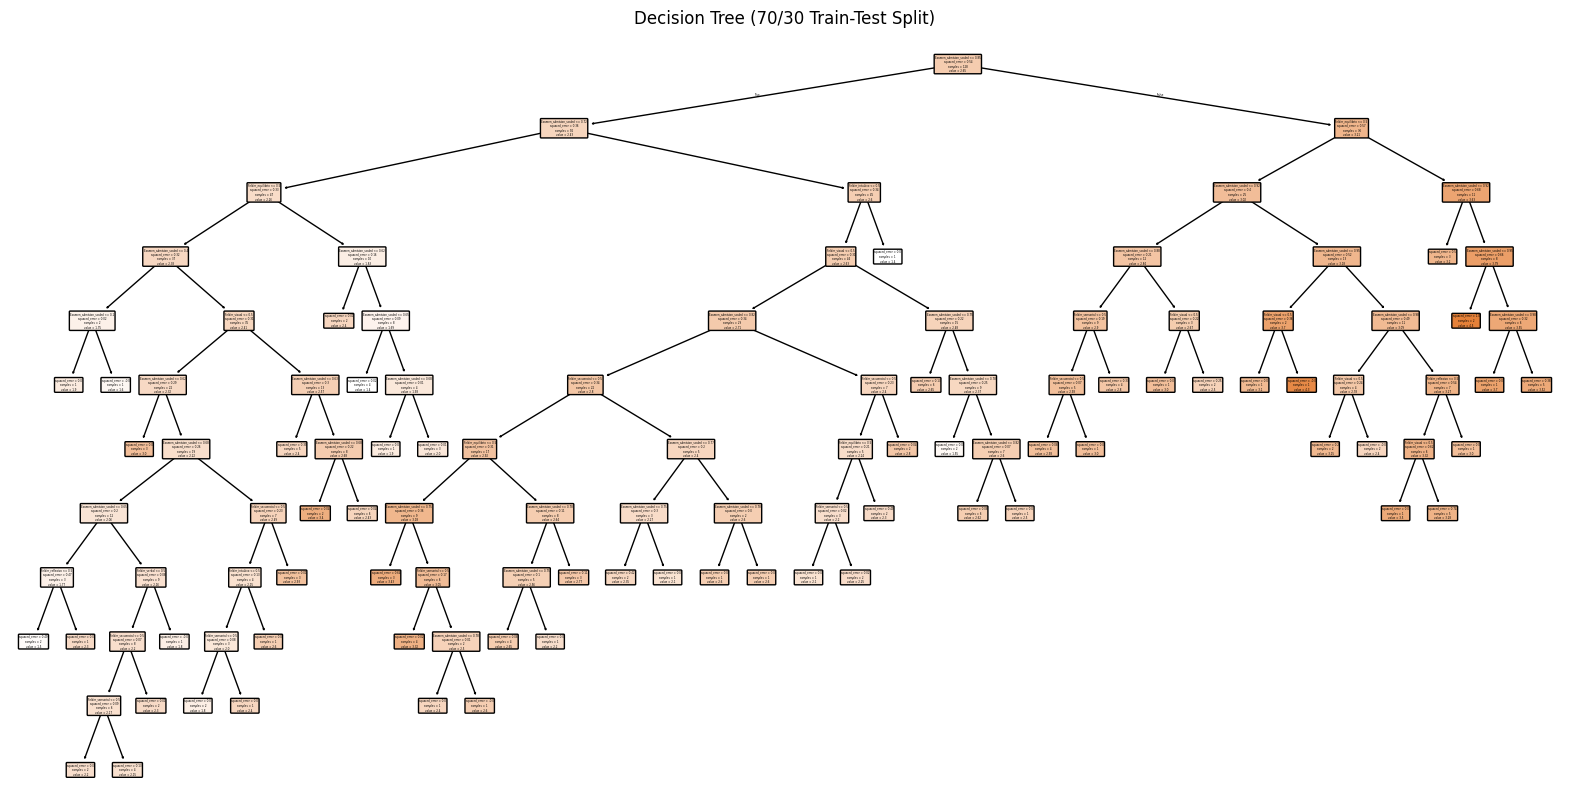


--- Decision Tree Model with Cross-Validation ---
Average MAE (Cross-Validation): 0.5184 (+/- 0.0810)
Average MSE (Cross-Validation): 0.4904 (+/- 0.1193)
Average RMSE (Cross-Validation): 0.6947 (+/- 0.0878)
Average R2 (Cross-Validation): 0.0644 (+/- 0.2344)


In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming X and y are already defined from previous cells
# X = df.drop(columns=['Nota_final'])
# y = df['Nota_final']

print("--- Decision Tree Model with 70/30 Train-Test Split ---")

# 1. Model with 70/30 Train-Test Split
X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30 = train_test_split(X, y, test_size=0.3, random_state=42)

dtree_70_30 = DecisionTreeRegressor(random_state=42)
dtree_70_30.fit(X_train_70_30, y_train_70_30)

y_pred_70_30 = dtree_70_30.predict(X_test_70_30)

mae_70_30 = mean_absolute_error(y_test_70_30, y_pred_70_30)
mse_70_30 = mean_squared_error(y_test_70_30, y_pred_70_30)
rmse_70_30 = np.sqrt(mse_70_30)
r2_70_30 = r2_score(y_test_70_30, y_pred_70_30)

print(f"MAE (70/30 Split): {mae_70_30:.4f}")
print(f"MSE (70/30 Split): {mse_70_30:.4f}")
print(f"RMSE (70/30 Split): {rmse_70_30:.4f}")
print(f"R2 (70/30 Split): {r2_70_30:.4f}")

# Plotting the Decision Tree from 70/30 split
plt.figure(figsize=(20, 10))
plot_tree(dtree_70_30, filled=True, feature_names=X.columns.tolist(), rounded=True, precision=2)
plt.title("Decision Tree (70/30 Train-Test Split)")
plt.show()

print("\n--- Decision Tree Model with Cross-Validation ---")

# 2. Model with Cross-Validation
dtree_cv = DecisionTreeRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores = -cross_val_score(dtree_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(dtree_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(dtree_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (Cross-Validation): {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")
print(f"Average MSE (Cross-Validation): {mse_scores.mean():.4f} (+/- {mse_scores.std():.4f})")
print(f"Average RMSE (Cross-Validation): {np.sqrt(mse_scores).mean():.4f} (+/- {np.sqrt(mse_scores).std():.4f})")
print(f"Average R2 (Cross-Validation): {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")

genera el MAPE para ambos modelos

In [9]:
from sklearn.model_selection import KFold
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Handle cases where y_true is zero to avoid division by zero.
    # Replace 0 with a small epsilon or skip those points.
    # For simplicity, we'll ignore entries where y_true is 0, or consider it as 100% error if y_pred is not 0.
    # A common approach is to filter out y_true == 0 or add a small epsilon.
    # Here, we'll filter for calculation, but be aware of implications.
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if all true values are zero

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- Mean Absolute Percentage Error (MAPE) ---")

# MAPE for 70/30 Train-Test Split Model
mape_70_30 = mean_absolute_percentage_error(y_test_70_30, y_pred_70_30)
print(f"MAPE (70/30 Split): {mape_70_30:.4f}%")

# MAPE for Cross-Validation Model
# Need to re-run cross-validation to get predictions for each fold

dtree_cv = DecisionTreeRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mape_scores_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    dtree_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = dtree_cv.predict(X_test_cv)

    mape_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv)
    mape_scores_cv.append(mape_cv)

mape_scores_cv = np.array(mape_scores_cv)

print(f"Average MAPE (Cross-Validation): {mape_scores_cv.mean():.4f}% (+/- {mape_scores_cv.std():.4f}%) ")

--- Mean Absolute Percentage Error (MAPE) ---
MAPE (70/30 Split): 23.8112%
Average MAPE (Cross-Validation): 21.8709% (+/- 4.5321%) 


Entrena un modelo ramdon forest con cross validation y calcula las metricas incluyendo el MAPE

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuse the MAPE function defined previously
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- Random Forest Regressor with Cross-Validation ---")

# Initialize Random Forest Regressor
rf_cv = RandomForestRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores_rf = -cross_val_score(rf_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_rf = -cross_val_score(rf_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_rf = cross_val_score(rf_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (Random Forest CV): {mae_scores_rf.mean():.4f} (+/- {mae_scores_rf.std():.4f})")
print(f"Average MSE (Random Forest CV): {mse_scores_rf.mean():.4f} (+/- {mse_scores_rf.std():.4f})")
print(f"Average RMSE (Random Forest CV): {np.sqrt(mse_scores_rf).mean():.4f} (+/- {np.sqrt(mse_scores_rf).std():.4f})")
print(f"Average R2 (Random Forest CV): {r2_scores_rf.mean():.4f} (+/- {r2_scores_rf.std():.4f})")

# Calculate MAPE for Cross-Validation Model
mape_scores_rf_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    rf_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_rf = rf_cv.predict(X_test_cv)

    mape_rf_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_rf)
    mape_scores_rf_cv.append(mape_rf_cv)

mape_scores_rf_cv = np.array(mape_scores_rf_cv)

print(f"Average MAPE (Random Forest CV): {mape_scores_rf_cv.mean():.4f}% (+/- {mape_scores_rf_cv.std():.4f}%)")

--- Random Forest Regressor with Cross-Validation ---
Average MAE (Random Forest CV): 0.4999 (+/- 0.0492)
Average MSE (Random Forest CV): 0.4279 (+/- 0.0654)
Average RMSE (Random Forest CV): 0.6522 (+/- 0.0511)
Average R2 (Random Forest CV): 0.1814 (+/- 0.1228)
Average MAPE (Random Forest CV): 21.2780% (+/- 3.3974%)


Entrena modelos KNN con cross validation para diferentes valores de K, calcula las metricas

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Reuse the MAPE function defined previously
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- K-Nearest Neighbors (KNN) with Cross-Validation ---")

# Define a range of K values to test
k_values = [3, 5, 7, 9, 11]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for k in k_values:
    print(f"\nEvaluating KNN with K={k}")
    knn = KNeighborsRegressor(n_neighbors=k)

    # Calculate standard metrics using cross_val_score
    mae_scores_knn = -cross_val_score(knn, X, y, cv=kf, scoring='neg_mean_absolute_error')
    mse_scores_knn = -cross_val_score(knn, X, y, cv=kf, scoring='neg_mean_squared_error')
    r2_scores_knn = cross_val_score(knn, X, y, cv=kf, scoring='r2')

    # Calculate MAPE for each fold
    mape_scores_knn_cv = []
    for train_index, test_index in kf.split(X):
        X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

        knn.fit(X_train_cv, y_train_cv)
        y_pred_cv_knn = knn.predict(X_test_cv)

        mape_knn_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_knn)
        mape_scores_knn_cv.append(mape_knn_cv)

    mape_scores_knn_cv = np.array(mape_scores_knn_cv)

    results[k] = {
        'MAE': {'mean': mae_scores_knn.mean(), 'std': mae_scores_knn.std()},
        'MSE': {'mean': mse_scores_knn.mean(), 'std': mse_scores_knn.std()},
        'RMSE': {'mean': np.sqrt(mse_scores_knn).mean(), 'std': np.sqrt(mse_scores_knn).std()},
        'R2': {'mean': r2_scores_knn.mean(), 'std': r2_scores_knn.std()},
        'MAPE': {'mean': mape_scores_knn_cv.mean(), 'std': mape_scores_knn_cv.std()},
    }

    print(f"  Average MAE: {results[k]['MAE']['mean']:.4f} (+/- {results[k]['MAE']['std']:.4f})")
    print(f"  Average MSE: {results[k]['MSE']['mean']:.4f} (+/- {results[k]['MSE']['std']:.4f})")
    print(f"  Average RMSE: {results[k]['RMSE']['mean']:.4f} (+/- {results[k]['RMSE']['std']:.4f})")
    print(f"  Average R2: {results[k]['R2']['mean']:.4f} (+/- {results[k]['R2']['std']:.4f})")
    print(f"  Average MAPE: {results[k]['MAPE']['mean']:.4f}% (+/- {results[k]['MAPE']['std']:.4f}%)")

--- K-Nearest Neighbors (KNN) with Cross-Validation ---

Evaluating KNN with K=3
  Average MAE: 0.5465 (+/- 0.0569)
  Average MSE: 0.4781 (+/- 0.0771)
  Average RMSE: 0.6891 (+/- 0.0572)
  Average R2: 0.0909 (+/- 0.1072)
  Average MAPE: 23.5814% (+/- 4.1130%)

Evaluating KNN with K=5
  Average MAE: 0.5153 (+/- 0.0659)
  Average MSE: 0.4382 (+/- 0.0821)
  Average RMSE: 0.6591 (+/- 0.0618)
  Average R2: 0.1574 (+/- 0.1800)
  Average MAPE: 22.7548% (+/- 5.1922%)

Evaluating KNN with K=7
  Average MAE: 0.5150 (+/- 0.0520)
  Average MSE: 0.4399 (+/- 0.0659)
  Average RMSE: 0.6615 (+/- 0.0484)
  Average R2: 0.1494 (+/- 0.1729)
  Average MAPE: 22.8510% (+/- 4.7121%)

Evaluating KNN with K=9
  Average MAE: 0.5241 (+/- 0.0480)
  Average MSE: 0.4677 (+/- 0.0648)
  Average RMSE: 0.6822 (+/- 0.0478)
  Average R2: 0.1039 (+/- 0.1311)
  Average MAPE: 23.2978% (+/- 4.1505%)

Evaluating KNN with K=11
  Average MAE: 0.5218 (+/- 0.0442)
  Average MSE: 0.4615 (+/- 0.0584)
  Average RMSE: 0.6779 (+/- 0.04

entrena un modelo de soporte vectorial svm con cross valiation y genera las metricas incluyendo el MAPE

In [12]:
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuse the MAPE function defined previously (assuming it's in the kernel's memory)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- Support Vector Regressor (SVR) with Cross-Validation ---")

# Initialize SVR model
# Using default kernel='rbf', C=1.0, epsilon=0.1
svr_cv = SVR(kernel='rbf')
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores_svr = -cross_val_score(svr_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_svr = -cross_val_score(svr_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_svr = cross_val_score(svr_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (SVR CV): {mae_scores_svr.mean():.4f} (+/- {mae_scores_svr.std():.4f})")
print(f"Average MSE (SVR CV): {mse_scores_svr.mean():.4f} (+/- {mse_scores_svr.std():.4f})")
print(f"Average RMSE (SVR CV): {np.sqrt(mse_scores_svr).mean():.4f} (+/- {np.sqrt(mse_scores_svr).std():.4f})")
print(f"Average R2 (SVR CV): {r2_scores_svr.mean():.4f} (+/- {r2_scores_svr.std():.4f})")

# Calculate MAPE for Cross-Validation Model
mape_scores_svr_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    svr_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_svr = svr_cv.predict(X_test_cv)

    mape_svr_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_svr)
    mape_scores_svr_cv.append(mape_svr_cv)

mape_scores_svr_cv = np.array(mape_scores_svr_cv)

print(f"Average MAPE (SVR CV): {mape_scores_svr_cv.mean():.4f}% (+/- {mape_scores_svr_cv.std():.4f}%)")

--- Support Vector Regressor (SVR) with Cross-Validation ---
Average MAE (SVR CV): 0.5023 (+/- 0.0511)
Average MSE (SVR CV): 0.4201 (+/- 0.0863)
Average RMSE (SVR CV): 0.6444 (+/- 0.0695)
Average R2 (SVR CV): 0.2076 (+/- 0.1037)
Average MAPE (SVR CV): 22.3779% (+/- 3.9141%)


entrene un modelo de red neuronal con cross validation y genere las metricas

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuse the MAPE function defined previously (assuming it's in the kernel's memory)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- Neural Network (MLPRegressor) with Cross-Validation ---")

# Initialize MLPRegressor model
# Using a simple architecture for demonstration (e.g., one hidden layer with 100 neurons)
# It's important to scale features for NNs, which we have already done for 'Examen_admision_scaled'
# and one-hot encoding implies a form of scaling for categorical features.
mlp_cv = MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42, solver='adam')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores_mlp = -cross_val_score(mlp_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_mlp = -cross_val_score(mlp_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_mlp = cross_val_score(mlp_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (MLP CV): {mae_scores_mlp.mean():.4f} (+/- {mae_scores_mlp.std():.4f})")
print(f"Average MSE (MLP CV): {mse_scores_mlp.mean():.4f} (+/- {mse_scores_mlp.std():.4f})")
print(f"Average RMSE (MLP CV): {np.sqrt(mse_scores_mlp).mean():.4f} (+/- {np.sqrt(mse_scores_mlp).std():.4f})")
print(f"Average R2 (MLP CV): {r2_scores_mlp.mean():.4f} (+/- {r2_scores_mlp.std():.4f})")

# Calculate MAPE for Cross-Validation Model
mape_scores_mlp_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    mlp_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_mlp = mlp_cv.predict(X_test_cv)

    mape_mlp_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_mlp)
    mape_scores_mlp_cv.append(mape_mlp_cv)

mape_scores_mlp_cv = np.array(mape_scores_mlp_cv)

print(f"Average MAPE (MLP CV): {mape_scores_mlp_cv.mean():.4f}% (+/- {mape_scores_mlp_cv.std():.4f}%) ")

--- Neural Network (MLPRegressor) with Cross-Validation ---
Average MAE (MLP CV): 0.5271 (+/- 0.0417)
Average MSE (MLP CV): 0.4661 (+/- 0.0946)
Average RMSE (MLP CV): 0.6791 (+/- 0.0704)
Average R2 (MLP CV): 0.1215 (+/- 0.0926)
Average MAPE (MLP CV): 23.6135% (+/- 3.5881%) 


Entrena un modelo bagginG con cross validation, genera las metricas incluyendo el MAPE

In [14]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuse the MAPE function defined previously (assuming it's in the kernel's memory)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- Bagging Regressor with Cross-Validation ---")

# Initialize Bagging Regressor model
bagging_cv = BaggingRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores_bagging = -cross_val_score(bagging_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_bagging = -cross_val_score(bagging_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_bagging = cross_val_score(bagging_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (Bagging CV): {mae_scores_bagging.mean():.4f} (+/- {mae_scores_bagging.std():.4f})")
print(f"Average MSE (Bagging CV): {mse_scores_bagging.mean():.4f} (+/- {mse_scores_bagging.std():.4f})")
print(f"Average RMSE (Bagging CV): {np.sqrt(mse_scores_bagging).mean():.4f} (+/- {np.sqrt(mse_scores_bagging).std():.4f})")
print(f"Average R2 (Bagging CV): {r2_scores_bagging.mean():.4f} (+/- {r2_scores_bagging.std():.4f})")

# Calculate MAPE for Cross-Validation Model
mape_scores_bagging_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    bagging_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_bagging = bagging_cv.predict(X_test_cv)

    mape_bagging_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_bagging)
    mape_scores_bagging_cv.append(mape_bagging_cv)

mape_scores_bagging_cv = np.array(mape_scores_bagging_cv)

print(f"Average MAPE (Bagging CV): {mape_scores_bagging_cv.mean():.4f}% (+/- {mape_scores_bagging_cv.std():.4f}%) ")

--- Bagging Regressor with Cross-Validation ---
Average MAE (Bagging CV): 0.5061 (+/- 0.0525)
Average MSE (Bagging CV): 0.4412 (+/- 0.0720)
Average RMSE (Bagging CV): 0.6619 (+/- 0.0560)
Average R2 (Bagging CV): 0.1580 (+/- 0.1248)
Average MAPE (Bagging CV): 21.4106% (+/- 3.6612%) 


entrena un modelo boosting con cross validation y genera las mertricas incluyendo MAPE

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuse the MAPE function defined previously (assuming it's in the kernel's memory)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print("--- GradientBoostingRegressor with Cross-Validation ---")

# Initialize GradientBoostingRegressor model
gbr_cv = GradientBoostingRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using various metrics
mae_scores_gbr = -cross_val_score(gbr_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_gbr = -cross_val_score(gbr_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_gbr = cross_val_score(gbr_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (GBR CV): {mae_scores_gbr.mean():.4f} (+/- {mae_scores_gbr.std():.4f})")
print(f"Average MSE (GBR CV): {mse_scores_gbr.mean():.4f} (+/- {mse_scores_gbr.std():.4f})")
print(f"Average RMSE (GBR CV): {np.sqrt(mse_scores_gbr).mean():.4f} (+/- {np.sqrt(mse_scores_gbr).std():.4f})")
print(f"Average R2 (GBR CV): {r2_scores_gbr.mean():.4f} (+/- {r2_scores_gbr.std():.4f})")

# Calculate MAPE for Cross-Validation Model
mape_scores_gbr_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    gbr_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_gbr = gbr_cv.predict(X_test_cv)

    mape_gbr_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_gbr)
    mape_scores_gbr_cv.append(mape_gbr_cv)

mape_scores_gbr_cv = np.array(mape_scores_gbr_cv)

print(f"Average MAPE (GBR CV): {mape_scores_gbr_cv.mean():.4f}% (+/- {mape_scores_gbr_cv.std():.4f}%) ")

--- GradientBoostingRegressor with Cross-Validation ---
Average MAE (GBR CV): 0.5085 (+/- 0.0526)
Average MSE (GBR CV): 0.4341 (+/- 0.0733)
Average RMSE (GBR CV): 0.6565 (+/- 0.0559)
Average R2 (GBR CV): 0.1673 (+/- 0.1558)
Average MAPE (GBR CV): 21.7508% (+/- 3.3975%) 


entrena un modelo stacking con cross validation y genera las mertricas de evaluacion incluyendo MAPE

In [16]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reusar la función MAPE definida anteriormente
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print("--- Stacking Regressor with Cross-Validation ---")

# Definir los estimadores base
base_estimators = [
    ('rf', RandomForestRegressor(random_state=42)),
    ('gbr', GradientBoostingRegressor(random_state=42)),
    ('svr', SVR(kernel='rbf'))
]

# Definir el meta-modelo
final_estimator = LinearRegression()

# Inicializar el Stacking Regressor
stacking_cv = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar usando métricas estándar mediante cross_val_score
mae_scores_stack = -cross_val_score(stacking_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')
mse_scores_stack = -cross_val_score(stacking_cv, X, y, cv=kf, scoring='neg_mean_squared_error')
r2_scores_stack = cross_val_score(stacking_cv, X, y, cv=kf, scoring='r2')

print(f"Average MAE (Stacking CV): {mae_scores_stack.mean():.4f} (+/- {mae_scores_stack.std():.4f})")
print(f"Average MSE (Stacking CV): {mse_scores_stack.mean():.4f} (+/- {mse_scores_stack.std():.4f})")
print(f"Average RMSE (Stacking CV): {np.sqrt(mse_scores_stack).mean():.4f} (+/- {np.sqrt(mse_scores_stack).std():.4f})")
print(f"Average R2 (Stacking CV): {r2_scores_stack.mean():.4f} (+/- {r2_scores_stack.std():.4f})")

# Calcular MAPE para cada fold de Cross-Validation
mape_scores_stack_cv = []
for train_index, test_index in kf.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    stacking_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv_stack = stacking_cv.predict(X_test_cv)

    mape_stack_cv = mean_absolute_percentage_error(y_test_cv, y_pred_cv_stack)
    mape_scores_stack_cv.append(mape_stack_cv)

mape_scores_stack_cv = np.array(mape_scores_stack_cv)

print(f"Average MAPE (Stacking CV): {mape_scores_stack_cv.mean():.4f}% (+/- {mape_scores_stack_cv.std():.4f}%)")

--- Stacking Regressor with Cross-Validation ---
Average MAE (Stacking CV): 0.4864 (+/- 0.0469)
Average MSE (Stacking CV): 0.3915 (+/- 0.0722)
Average RMSE (Stacking CV): 0.6228 (+/- 0.0599)
Average R2 (Stacking CV): 0.2595 (+/- 0.0851)
Average MAPE (Stacking CV): 21.2871% (+/- 3.4629%)
